# 03 — A third method: computing the cable contribution from physics

**What this notebook is.** Notebook 02 used statistics to separate the demand-side
("organic") drift from the cable contribution, and was honest that the *exact* split is
weakly pinned by statistics alone. This notebook attacks the same question a completely
different way: it **computes** how much leading reactive power the network's cables and
lines inject, from first-principles physics, using only published line lengths. No fitted
coefficient, so it sidesteps the weak-identification problem entirely. If a physics
calculation and a statistical regression — which share none of their assumptions — land in
the same place, the conclusion is robust.

**The physics in one line.** Any length of cable or overhead line, energised at a voltage,
behaves like a distributed capacitor and injects a fixed amount of leading (capacitive)
reactive power: **Q = ω · C · V² · length**, where ω = 2π·50 Hz, C is the line's capacitance
per km, and V is the operating voltage. Underground cable has far more capacitance per km
than overhead wire (it has a dielectric and the conductors sit close together), which is why
cable-heavy networks inject more.

**Bottom line (two distinct findings — keep them apart):**

1. **DRIFT.** Cable length grows slowly, so the *physical charging* barely changes year to
   year. Therefore almost all of the 29-year *worsening trend* must be organic. This notebook
   puts that at **~75–88% organic of the drift** — agreeing with notebook 02's two methods.
   Three independent methods now concur. **[I], approaching [V].**
2. **LEVEL.** Of the total leading reactive power standing on the network *today*, physics
   attributes a **large, near-static baseline** to cable/line charging, leaving a smaller
   organic remainder. This LEVEL share is genuinely uncertain (wide physical band) and is a
   **different question** from the drift. We carry it as **[H]** and never let it be confused
   with the drift finding.

In [1]:
import sys
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for _cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_cand / "repro.py").exists():
        sys.path.insert(0, str(_cand))
        break
import repro
repro.set_style()
warnings.filterwarnings("ignore")

OMEGA = 2 * np.pi * 50.0   # angular frequency, rad/s, at NZ's 50 Hz
disc = pd.read_parquet(repro.comcom_parquet())
panel = pd.read_parquet(repro.CACHE / "gxp_year_panel.parquet")
print("Loaded Commerce-Commission disclosures and the GXP panel.")

Loaded Commerce-Commission disclosures and the GXP panel.


## 1. The capacitance assumptions — stated openly, with a physical uncertainty band

**Plain bottom line.** The only quantity we do not read directly from public data is the
capacitance per km of each kind of line at each voltage. We use standard textbook
distribution values, and — crucially — we carry a wide **±35%** band around the cable
figures, propagate it through everything, and report the resulting range. The uncertainty in
the final answer is therefore *physical and explicit*, not hidden.

**What each number means and why it is reasonable.**

- **Underground cable** has high capacitance per km (≈0.13–0.6 µF/km depending on voltage):
  close-spaced conductors and a solid insulating dielectric. This is the dominant source of
  network leading reactive power.
- **Overhead line** has ~20–30× *less* capacitance (≈0.01 µF/km): wide air spacing, no
  dielectric. This is the small but non-zero "overhead-charging floor" — overhead lines are
  not *exactly* zero, and we include them so we do not understate the network share.
- **SWER** (single-wire earth return — a one-wire rural line that uses the ground as the
  return path) carries roughly one-third of a normal three-phase circuit's charging; we apply
  a 0.33 factor.

**Glossary:** *µF/km* = microfarads per kilometre, the unit of capacitance per length.
*Dielectric* = the insulating material around a cable's conductor. *Three-phase* = the
standard arrangement of three live conductors; SWER is a cheap rural single-wire variant.

In [2]:
# Per voltage band: (nominal kV, cable C µF/km, overhead C µF/km, phase factor).
# Central values are textbook distribution figures; the ±35% band on cable C is applied below.
BANDS = {
    "> 66kV":                                    (110.0, 0.13,  0.011,  1.0),
    "50kV & 66kV":                               (66.0,  0.14,  0.010,  1.0),
    "33kV":                                      (33.0,  0.18,  0.010,  1.0),
    "22kV (other than SWER)":                    (22.0,  0.20,  0.0095, 1.0),
    "6.6kV to 11kV (inclusive-other than SWER)": (11.0,  0.25,  0.009,  1.0),
    "SWER (all SWER voltages)":                  (12.7,  0.20,  0.009,  0.33),
    "Low voltage (< 1kV)":                       (0.40,  0.60,  0.010,  1.0),
}
C_LO, C_HI = 0.65, 1.35   # the ±35% physical band on cable capacitance


def band_charging(ug_km, oh_km, V_kV, C_ug, C_oh, phase):
    """Three-phase capacitive (leading) reactive power for one voltage band, in MVAr."""
    V = V_kV * 1e3
    q = OMEGA * (C_ug * 1e-6) * V**2 * ug_km + OMEGA * (C_oh * 1e-6) * V**2 * oh_km
    return phase * q / 1e6


print("Capacitance assumptions loaded for 7 voltage bands; cable band ±35% (0.65×–1.35×).")
print("These are the ONLY non-public-data inputs — everything else is measured.")

Capacitance assumptions loaded for 7 voltage bands; cable band ±35% (0.65×–1.35×).
These are the ONLY non-public-data inputs — everything else is measured.


## 2. Add up the physical charging per network per year

**What we do.** From Commerce-Commission Schedule 9c we read each network's overhead and
underground kilometres *at each voltage*, multiply by the physics, and sum. Doing it band by
band (rather than with one average voltage) matters because charging scales with the *square*
of voltage, so the higher-voltage lines count for much more.

In [3]:
def edb_charging(cmult):
    """Per-(network, year) physical charging MVAr (leading), with cable C scaled by cmult."""
    s9c = disc[disc.schedule.str.startswith("SCHEDULE 9c")
               & (disc.category == "Circuit length by operating voltage (at year end)")
               & (disc.network == "All")
               & disc.sub_category.isin(["Overhead (km)", "Underground (km)"])]
    rows = []
    for (edb, yr), g in s9c.groupby(["edb", "obs_yr"]):
        total = 0.0
        for band, (V, C_ug, C_oh, phase) in BANDS.items():
            b = g[g.description == band]
            ug = b[b.sub_category == "Underground (km)"].value.sum()
            oh = b[b.sub_category == "Overhead (km)"].value.sum()
            total += band_charging(ug, oh, V, C_ug * cmult, C_oh * cmult, phase)
        rows.append(dict(emi_code=repro.COMCOM_TO_EMI.get(edb), edb=edb,
                         year=int(yr), charge=total))
    return pd.DataFrame(rows).dropna(subset=["emi_code"])


charge_c = edb_charging(1.0).rename(columns={"charge": "charge_c"})
charge_c["charge_lo"] = edb_charging(C_LO).charge.values
charge_c["charge_hi"] = edb_charging(C_HI).charge.values

# Measured overnight reactive per network-year (sign kept: Q<0 = leading). Use ALL demand GXPs
# (not just balanced) to match the full network footprint the cable km describe.
p = panel[~panel.edb.isin(repro.NON_EDB_CODES)]
meas = p.groupby(["edb", "year"]).on_Q.sum().reset_index().rename(columns={"on_Q": "measured"})

m = meas.merge(charge_c, left_on=["edb", "year"], right_on=["emi_code", "year"], how="inner")
print(f"Decomposition footprint: {m.edb_x.nunique()} networks, "
      f"years {int(m.year.min())}–{int(m.year.max())}, {len(m)} network-years.")

Decomposition footprint: 29 networks, years 2013–2025, 376 network-years.


## 3. Subtract the physics from the measurement — what's left is organic

**The accounting (and the sign care that makes or breaks it).** Charging is *leading*, which
in our convention is *negative*. So the measured overnight reactive power is the organic part
**plus** a negative charging term:

`measured_Q = organic_Q + (−charging)`  ⟹  `organic_Q = measured_Q + charging`

We add the physical charging back onto the measurement to recover the organic remainder. We
do this three times — with low, central, and high cable capacitance — to carry the physical
band through to the answer.

In [4]:
for tag in ["c", "lo", "hi"]:
    m[f"organic_{tag}"] = m.measured + m[f"charge_{tag}"]

nat = m.groupby("year").agg(
    measured=("measured", "sum"),
    charge_c=("charge_c", "sum"), charge_lo=("charge_lo", "sum"), charge_hi=("charge_hi", "sum"),
    organic_c=("organic_c", "sum"), organic_lo=("organic_lo", "sum"), organic_hi=("organic_hi", "sum"),
).reset_index()

print("National overnight reactive decomposition (MVAr; <0 = leading):")
print(f"  {'year':>4}  {'measured':>9}  {'charging(phys)':>15}  {'organic(residual)':>18}")
for _, r in nat.iterrows():
    print(f"  {int(r.year):>4}  {r.measured:>9.0f}  "
          f"{-r.charge_c:>8.0f} [{-r.charge_hi:.0f},{-r.charge_lo:.0f}]  "
          f"{r.organic_c:>9.0f} [{r.organic_hi:.0f},{r.organic_lo:.0f}]")

National overnight reactive decomposition (MVAr; <0 = leading):
  year   measured   charging(phys)   organic(residual)
  2013         22      -334 [-450,-217]        355 [472,238]
  2014         17      -349 [-471,-227]        365 [487,243]
  2015        -11      -373 [-503,-242]        362 [493,232]
  2016        -81      -387 [-522,-251]        305 [441,170]
  2017       -120      -395 [-533,-257]        275 [413,137]
  2018       -182      -400 [-540,-260]        218 [358,78]
  2019       -211      -410 [-553,-266]        199 [342,55]
  2020       -268      -423 [-571,-275]        155 [303,7]
  2021       -331      -422 [-569,-274]         91 [238,-57]
  2022       -389      -428 [-578,-278]         39 [189,-111]
  2023       -447      -439 [-592,-285]         -9 [145,-162]
  2024       -489      -447 [-603,-290]        -42 [114,-198]
  2025       -541      -454 [-613,-295]        -87 [72,-246]


## 4. The DRIFT result — agreeing with notebook 02 [I → V]

**Plain bottom line.** The physical charging line is almost flat (cable grows slowly), so
the *trend* in measured reactive power is almost entirely the *organic* trend. This is the
physics reason the drift is dominantly demand-side — and it lands on the same ~75–88% as the
two statistical methods, despite sharing none of their assumptions.

In [5]:
def slope(y, x):
    mask = np.isfinite(x) & np.isfinite(y)
    return np.polyfit(np.asarray(x)[mask], np.asarray(y)[mask], 1)[0]


s_meas = slope(nat.measured, nat.year)
s_charge = slope(-nat.charge_c, nat.year)
s_org = slope(nat.organic_c, nat.year)
s_org_lo = slope(nat.organic_lo, nat.year)   # high cable C -> least organic
s_org_hi = slope(nat.organic_hi, nat.year)
yr0, yr1 = int(nat.year.min()), int(nat.year.max())
print(f"Drift over {yr0}–{yr1} (MVAr/yr; <0 = going leading):")
print(f"  measured drift = {s_meas:+.1f}/yr")
print(f"  charging drift = {s_charge:+.1f}/yr   (~static: cable length grows slowly)")
print(f"  organic  drift = {s_org:+.1f}/yr")
print(f"\n  ORGANIC SHARE OF THE DRIFT = {s_org/s_meas*100:.0f}%  "
      f"(physical band {s_org_lo/s_meas*100:.0f}–{s_org_hi/s_meas*100:.0f}%)  [I -> V]")
print("\nNote: this all-network physical footprint drifts at "
      f"{s_meas:+.1f} MVAr/yr over {yr0}–{yr1}. That is a DIFFERENT dataset from the")
print("balanced-panel spine (-30.3 MVAr/yr, 132 GXPs, 1997–2025) in notebooks 00–01 —")
print("different sample, different years. They must be labelled separately, never blended.")

Drift over 2013–2025 (MVAr/yr; <0 = going leading):
  measured drift = -49.9/yr
  charging drift = -9.2/yr   (~static: cable length grows slowly)
  organic  drift = -40.7/yr

  ORGANIC SHARE OF THE DRIFT = 82%  (physical band 88–75%)  [I -> V]

Note: this all-network physical footprint drifts at -49.9 MVAr/yr over 2013–2025. That is a DIFFERENT dataset from the
balanced-panel spine (-30.3 MVAr/yr, 132 GXPs, 1997–2025) in notebooks 00–01 —
different sample, different years. They must be labelled separately, never blended.


> **Numbers-spine discipline (charter rule, repeated because it is easy to slip).** There
> are three distinct rate numbers in this programme and they measure different things over
> different samples:
>
> | Number | Sample | Span | Meaning |
> |---|---|---|---|
> | **−30.3 MVAr/yr** | 132 balanced GXPs | 1997–2025 | the balanced-panel spine (notebook 01) |
> | **≈ −50 MVAr/yr** | all demand networks | 2013–2025 | the physical footprint (this notebook) |
> | **≈ 46 MVAr/yr** | cable-Q correlation | — | the earlier cable-correlation study |
>
> They are consistent in *direction and meaning* but are **not interchangeable figures**.
> Always say which one you mean.

## 5. The LEVEL result — a different, weaker claim [H]

**Plain bottom line.** Drift is "what's driving the worsening trend"; **level** is "what
makes up the leading reactive power standing on the network *right now*". These are different
questions and deserve different confidence. On the level, physics says a *large, near-static*
cable/line charging baseline has always been there; what changed is that the organic demand
shifted from *lagging* (which used to mask the charging) toward *leading* (which no longer
does). So today's net leading reactive is mostly the long-standing charging *revealed*, with
a smaller genuinely-organic addition. The exact level split has a wide band and is **[H]**.

In [6]:
last = nat.iloc[-1]
yr = int(last.year)
if last.measured < 0:
    share_c = last.organic_c / last.measured
    share_lo = last.organic_hi / last.measured     # high charging -> least organic
    share_hi = last.organic_lo / last.measured
    print(f"In {yr}, of {last.measured:.0f} MVAr net leading nationally:")
    print(f"  physical cable/line charging ≈ {-last.charge_c:.0f} MVAr "
          f"[{-last.charge_hi:.0f}, {-last.charge_lo:.0f}]")
    print(f"  organic remainder            ≈ {last.organic_c:.0f} MVAr "
          f"=> organic LEVEL share ≈ {share_c*100:.0f}% (band {share_lo*100:.0f}–{share_hi*100:.0f}%)  [H]")
    print("\nReading: the cables always injected this leading Q; the organic load shift REMOVED")
    print("the lagging 'cover' that used to mask it. The network is increasingly EXPOSED TO ITS")
    print("OWN CHARGING, unmanaged — which is the 'missing defence layer' the paper argues for.")

In 2025, of -541 MVAr net leading nationally:
  physical cable/line charging ≈ -454 MVAr [-613, -295]
  organic remainder            ≈ -87 MVAr => organic LEVEL share ≈ 16% (band -13–45%)  [H]

Reading: the cables always injected this leading Q; the organic load shift REMOVED
the lagging 'cover' that used to mask it. The network is increasingly EXPOSED TO ITS
OWN CHARGING, unmanaged — which is the 'missing defence layer' the paper argues for.


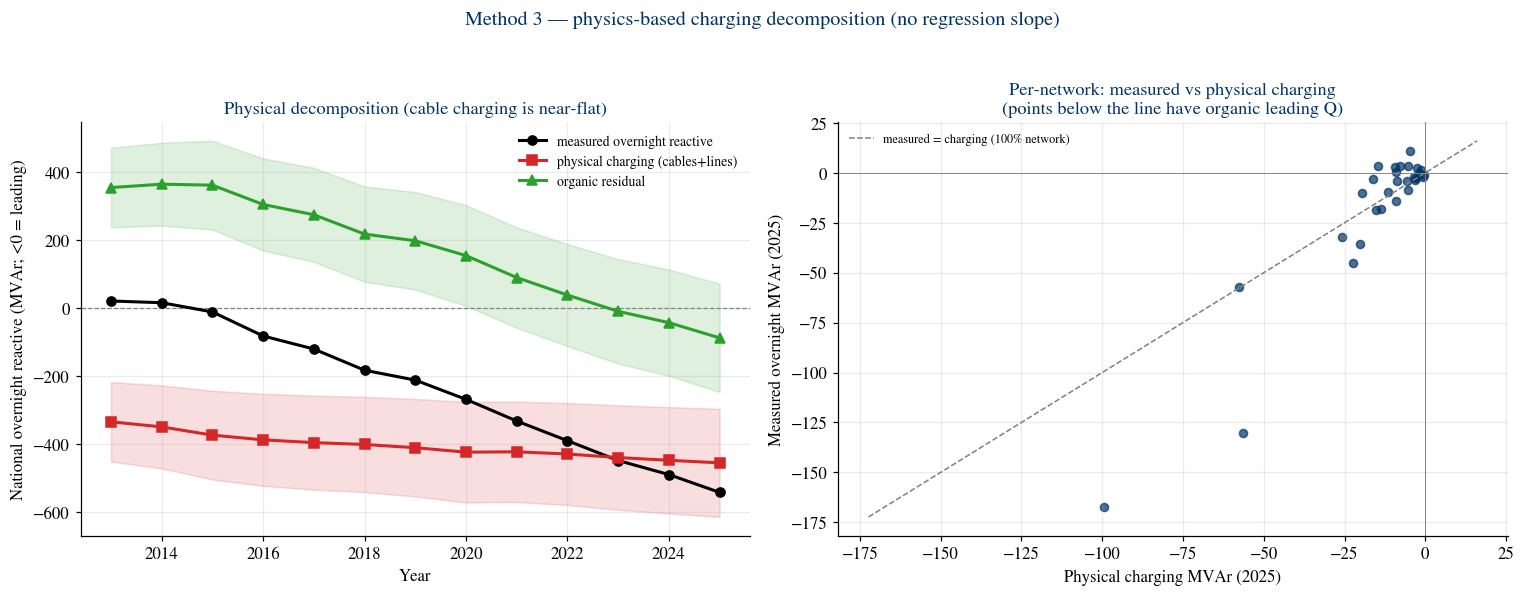

In [7]:
# Figure: the national decomposition over time, with the physical band shaded.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
ax1.axhline(0, color="grey", lw=0.8, ls="--")
ax1.plot(nat.year, nat.measured, "-o", color="black", lw=2, label="measured overnight reactive")
ax1.plot(nat.year, -nat.charge_c, "-s", color=repro.RED, lw=2, label="physical charging (cables+lines)")
ax1.fill_between(nat.year, -nat.charge_hi, -nat.charge_lo, color=repro.RED, alpha=0.15)
ax1.plot(nat.year, nat.organic_c, "-^", color=repro.GREEN, lw=2, label="organic residual")
ax1.fill_between(nat.year, nat.organic_hi, nat.organic_lo, color=repro.GREEN, alpha=0.15)
ax1.set_xlabel("Year"); ax1.set_ylabel("National overnight reactive (MVAr; <0 = leading)")
ax1.set_title("Physical decomposition (cable charging is near-flat)")
ax1.legend(fontsize=9)
last_m = m[m.year == yr]
ax2.scatter(-last_m.charge_c, last_m.measured, s=28, alpha=0.7, color=repro.EA_BLUE)
lim = [min(-last_m.charge_c.min(), last_m.measured.min()) - 5,
       max(-last_m.charge_c.max(), last_m.measured.max()) + 5]
ax2.plot(lim, lim, ls="--", color="grey", lw=1, label="measured = charging (100% network)")
ax2.axhline(0, color="grey", lw=0.6); ax2.axvline(0, color="grey", lw=0.6)
ax2.set_xlabel(f"Physical charging MVAr ({yr})"); ax2.set_ylabel(f"Measured overnight MVAr ({yr})")
ax2.set_title("Per-network: measured vs physical charging\n(points below the line have organic leading Q)")
ax2.legend(fontsize=8)
fig.suptitle("Method 3 — physics-based charging decomposition (no regression slope)", color=repro.EA_BLUE)
fig.tight_layout(rect=[0, 0, 1, 0.95]); fig.savefig(repro.FIGURES / "03_physical_charging.png"); plt.show()

## Verdict — three methods, one conclusion (for the drift)

- **Drift:** physics says ~75–88% of the worsening trend is organic, because cable charging
  barely changes over time. With notebook 02's clean-cohort (~75%) and validated dose-response
  (~78–93%), **three methods that share no assumptions all say the drift is dominantly
  demand-side.** Carry as **[I] approaching [V]**; the exact figure stays a range (~75–90%).
- **Level:** today's standing leading reactive is mostly long-standing cable charging that the
  organic shift *uncovered* — a narrative, in-person point, **[H]**, never to be quoted as a
  precise share or confused with the drift result.
- **Why this strengthens the paper:** the demand-side driver is not a statistical artefact —
  the physics independently requires it. And the "uncovered charging" framing is exactly the
  *missing defence layer* argument: the leading reactive was always coming; nothing in the
  rules priced, limited, monitored, or managed it.